# Notebook 03 — DenseNet121 for malaria cell images

**Colombe — Member 3.** This notebook is my model only: a pretrained DenseNet121, fine-tuned on the NIH malaria cell images.

The other models in the group are not mine:

- Qevin: custom ResNet, trained from scratch
- Peggy: MobileNetV2
- Gabriella: a hand-built Inception-style network

I import the shared data split from `common/data.py` so we all test on the same files. The model, the seven experiments, and the notes in this notebook are mine.

**How to run this**

1. Open the notebook from this project folder (the folder that contains `colombe/` and `common/`). Cursor, Jupyter, or Colab all work. Colab needs a GPU: Runtime → Change runtime type → T4.
2. Leave `RUN_MODE = "campaign"` for the real assignment. That trains all 7 runs. On a Colab T4 it takes a few hours. Finished runs are skipped if you restart, as long as the weights and the log folder are still there.
3. `RUN_MODE = "smoke"` uses a tiny fake dataset and random weights. Use it only to check that the notebook runs. Those numbers are not for the report.
4. After the campaign, fill in the blank interpretation cells in your own words. The report has to be your writing. Do not paste these markdown notes in as the report.


In [4]:
# Setup. Finds the project even if Jupyter started in notebooks/.
import os, sys, pathlib

def find_root() -> pathlib.Path:
    here = pathlib.Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "colombe" / "densenet.py").exists() and (candidate / "common" / "data.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find colombe/ and common/. Open this notebook from the project folder, "
        "or upload the whole project to Colab."
    )

ROOT = find_root()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import importlib.util
import subprocess
missing = [pkg for pkg in ("tensorboard", "pandas") if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

# "campaign" = real NIH images, ImageNet weights, all 7 runs.
# "smoke" = tiny synthetic images, random weights, one short run. Not for the report.
RUN_MODE = "campaign"
EPOCHS = 10          # early stopping can end a run sooner
FORCE_RERUN = False  # True deletes a finished run and trains it again

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")
    DRIVE = pathlib.Path("/content/drive/MyDrive/malaria_project")
    DRIVE.mkdir(parents=True, exist_ok=True)
    LOG_DIR = DRIVE / "logs" / "fit"
    MODEL_DIR = DRIVE / "models" / "densenet121"
    RESULTS = DRIVE / "results" / "densenet121"
    DRIVE_DATA = str(DRIVE / "data")
else:
    LOG_DIR = ROOT / "logs" / "fit"
    MODEL_DIR = ROOT / "models" / "densenet121"
    RESULTS = ROOT / "results" / "densenet121"
    DRIVE_DATA = "data"

for path in (LOG_DIR, MODEL_DIR, RESULTS):
    path.mkdir(parents=True, exist_ok=True)

import tensorflow as tf
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print("memory growth:", exc)

gpus = tf.config.list_physical_devices("GPU")
print("root:", ROOT)
print("mode:", RUN_MODE, "| epochs:", EPOCHS)
print("TF", tf.__version__, "| GPU:", gpus)
print("logs:", LOG_DIR)
if RUN_MODE == "campaign" and not gpus:
    print("No GPU detected. The 7 DenseNet121 runs are very slow on CPU. Use Google Colab with a T4.")


root: C:\Users\EVOTECH\Downloads\groupwork lastfromative\Malaria-CNN-Classification-Project-
mode: campaign | epochs: 10
TF 2.21.0 | GPU: []
logs: C:\Users\EVOTECH\Downloads\groupwork lastfromative\Malaria-CNN-Classification-Project-\logs\fit
No GPU detected. The 7 DenseNet121 runs are very slow on CPU. Use Google Colab with a T4.


### Why DenseNet121, and why this split

DenseNet (Huang et al., 2017) connects every layer to every earlier layer by **concatenation**, not by addition. That is the difference from Qevin's ResNet, which adds the skip. Peggy's MobileNetV2 is built to be small (depthwise convolutions, inverted residuals). I wanted the other transfer-learning family: a heavier net that keeps early texture filters available to the classifier. Parasite pigment is a small stain inside the cell, so those early filters are part of the reason I picked this backbone.

The shared loader is `build_datasets(..., validation_fraction=0.30, seed=42)`. It holds out 30% of the files, then cuts that holdout in half. That is **70% train / 15% validation / 15% test**. A 75/15/15 split does not add up to 100%, and it is not what this repository does. If someone saved a different split outside the repo, our test numbers will not be comparable. The check is the fingerprint printed below: Qevin, Peggy, and Gabriella should get the same hex string from the same function.

Labels: Keras would number the folders alphabetically, so Parasitized would be 0. The shared code flips that. **1 = Parasitized = infected.** Recall on that class is sensitivity. Specificity is the true-negative rate on Uninfected.

DenseNet's own `preprocess_input` is inside the model. It expects pixels in 0–255 and does the ImageNet BGR mean subtraction itself. I do not also divide by 255. Doing both would feed the pretrained filters the wrong color scale.

The transfer-learning target in the brief, for the held-out test set, is at least 95% sensitivity and 90% specificity. That is a target to discuss, not a switch that deletes a run. The custom models have a lower bar (90% / 90%) because they train from scratch.


In [5]:
# Inline plots when Jupyter has already imported pyplot. common/eval.py
# asks for the Agg backend; if pyplot is already loaded, that request is ignored.
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

from common.data import (
    SEED, get_data, build_datasets, split_fingerprint, make_synthetic_cell_dataset,
)
from colombe.densenet import (
    MODEL_NAME, default_experiments, build_densenet121, describe_model,
    run_campaign, best_by_val_loss, load_trained, evaluation_datasets,
    save_final_report_pack, write_results_csv,
)
from common.tb import make_run_name
import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)

if RUN_MODE == "smoke":
    cell_images = make_synthetic_cell_dataset(
        "data/_colombe_demo", per_class=12, img_size=(64, 64), seed=SEED
    )
    print("SMOKE data only. Do not put these numbers in the report.")
else:
    cell_images = get_data(drive_data_dir=DRIVE_DATA)

# Fingerprint at the group's default 128px, batch 16 (my batch size).
train_ds, val_ds, test_ds = build_datasets(
    cell_images, img_size=(128, 128), batch_size=16,
    validation_fraction=0.30, seed=SEED, augment=False,
)
print("seed", SEED, "| split 70/15/15")
print("train fingerprint:", split_fingerprint(train_ds))
print("val   fingerprint:", split_fingerprint(val_ds))
print("test  fingerprint:", split_fingerprint(test_ds))

def label_counts(ds):
    infected = uninfected = 0
    for _, y in ds:
        y = y.numpy().ravel()
        infected += int((y == 1).sum())
        uninfected += int((y == 0).sum())
    return infected, uninfected

for name, ds in (("train", train_ds), ("val", val_ds), ("test", test_ds)):
    infected, uninfected = label_counts(ds)
    print(f"{name}: infected={infected}  uninfected={uninfected}  total={infected + uninfected}")


Dataset ready: {'Parasitized': 13779, 'Uninfected': 13779} (total 27558)
Found 27558 files belonging to 2 classes.
Using 19291 files for training.
Using 8267 files for validation.
Split sizes (files): train~19296 (1206 batches, last may be partial), val=4133, test=4134
seed 42 | split 70/15/15
train fingerprint: 3540465fa43755e0
val   fingerprint: 97ecdb901657f08d
test  fingerprint: 2fa0f283b909b560
train: infected=9683  uninfected=9608  total=19291
val: infected=2052  uninfected=2081  total=4133
test: infected=2044  uninfected=2090  total=4134


### What the cells look like

The title under each image uses my label convention: 1 is parasitized, 0 is uninfected. I check this before any training. If the titles were swapped, every sensitivity number later would be wrong.


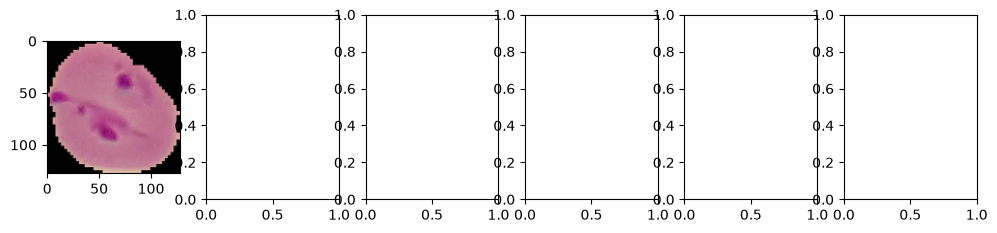

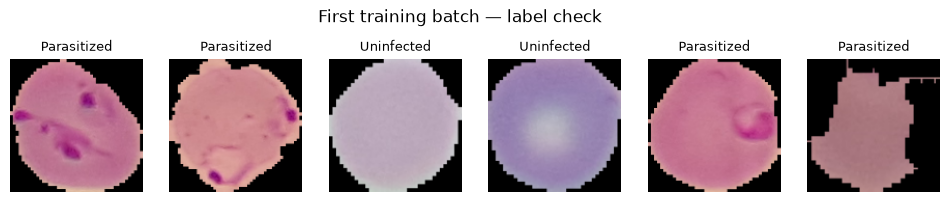

In [6]:
for images, labels in train_ds.take(1):
    fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
    for ax, image, label in zip(axes, images[:6], labels[:6]):
        ax.imshow(image.numpy().astype("uint8"))
        # label_mode="binary" gives shape (1,), so int(label) raises.
        ax.set_title("Parasitized" if int(tf.squeeze(label)) == 1 else "Uninfected", fontsize=9)
        ax.axis("off")
    fig.suptitle("First training batch — label check")
    plt.show()


### Architecture

ImageNet DenseNet121, without its original 1000-way head. On top of the last feature map I put:

1. Global average pooling
2. Dropout
3. A single linear unit (the logit)
4. A sigmoid, so the output is P(parasitized)

The sigmoid is its own layer. Grad-CAM uses the logit. If I differentiated the sigmoid instead, a very confident prediction (probability near 0 or 1) has a derivative near 0 and the heatmap comes out blank.

**What is frozen**

- Experiments 01–04: the whole backbone is frozen. Only the new dense layer trains.
- Experiment 05 and 07: layers from the start of `conv5` (the last dense block) can train. Learning rate is 1e-5, not 1e-3. A large step on pretrained filters tends to wipe them.
- Experiment 06: unfreeze from `conv4` as well, still at 1e-5. This is the run I expect to overfit, because more filters are free to adapt to about 19,000 training images.
- Batch-norm stays frozen in every run, including the fine-tuning runs. Batch size is 16. That is too small for stable batch statistics, and the ImageNet moving averages are already trained. If batch-norm updates, fine-tuning often gets worse.

The cell below prints how many weights actually train, and the name of the first layer in the unfrozen tail. I want that name to start with `conv5` or `conv4`, not with an early stem layer. If the first unfrozen layer were `conv1`, the fine-tune flag would be wrong.


In [7]:
import gc
from tensorflow import keras

probes = [("frozen", (128, 128)), ("conv5", (224, 224)), ("conv4", (224, 224))]
weight_source = None if RUN_MODE == "smoke" else "imagenet"
for finetune, size in probes:
    model = build_densenet121(img_size=size, finetune=finetune, weights=weight_source)
    print(f"{finetune} @ {size[0]}px |", describe_model(model))
    del model
    keras.backend.clear_session()
    gc.collect()



29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
frozen @ 128px | params total=7,038,529  trainable=1,025  tail_layers=0  first_tail_layer=none  strategy=frozen_head  trainable_bn=0
conv5 @ 224px | params total=7,038,529  trainable=2,130,945  tail_layers=114  first_tail_layer=conv5_block1_0_bn  strategy=finetune_conv5_bn_frozen  trainable_bn=0
conv4 @ 224px | params total=7,038,529  trainable=5,456,897  tail_layers=286  first_tail_layer=conv4_block1_0_bn  strategy=finetune_from_conv4_bn_frozen  trainable_bn=0


### The seven runs

Each run changes one decision from the run I compare it with. Batch size is 16 everywhere, including the 128px run, so batch size is not a hidden difference. 16 is what fits DenseNet121 at 224×224 on a Colab T4.

| Run name | What changes | Why I am running it |
|---|---|---|
| `densenet121_exp_01_baseline_frozen_128` | reference | How far do frozen ImageNet features get at the group's 128px size? |
| `densenet121_exp_02_input_224` | 128 → 224 only | DenseNet was pretrained at 224. Parasite texture is small; the extra pixels may matter. |
| `densenet121_exp_03_augment` | add flip / rotation / zoom | A cell has no canonical orientation. Augmentation is on the training split only. |
| `densenet121_exp_04_head_lr_1e-4` | head LR 1e-3 → 1e-4 | A slower head, before I let any backbone weight move. |
| `densenet121_exp_05_unfreeze_conv5` | unfreeze last dense block, LR 1e-5 | The fine-tune step. The LR drop is part of that decision, not a separate tweak. |
| `densenet121_exp_06_unfreeze_from_conv4` | also unfreeze conv4, same LR | Depth branch. If validation loss rises while training loss falls, this is the overfit run. |
| `densenet121_exp_07_final_conv5_dropout04` | back to conv5, dropout 0.3 → 0.4 | One change from exp 05. Slightly stronger head dropout on the shallower fine-tune. |

The run I plot at the end is whichever of these has the **lowest validation loss**, not the highest test score. The test metrics are still computed for every run, because the assignment table asks for them. I do not want to pick the winner by looking at the test set seven times and keeping the luckiest one.

TensorBoard run names are exactly the names in the table. Logs go to `logs/fit/` (or the Drive folder printed above, on Colab).


In [8]:
experiments = default_experiments()
if RUN_MODE == "smoke":
    smoke = dict(experiments[0])
    smoke["img_size"] = (64, 64)
    smoke["batch_size"] = 4
    experiments = [smoke]
    print("SMOKE: only exp 01, 64px, random weights, 1 step.")

for spec in experiments:
    print(make_run_name(MODEL_NAME, spec["id"], spec["name"]))
    print("   ", spec["note"])


densenet121_exp_01_baseline_frozen_128
    Frozen ImageNet trunk, new head only, 128px. Reference.
densenet121_exp_02_input_224
    Same frozen head, but 224px — the resolution DenseNet was pretrained at.
densenet121_exp_03_augment
    Add flips, small rotations, and zoom. Cells have no up/down.
densenet121_exp_04_head_lr_1e-4
    Lower the head learning rate before any backbone weights move.
densenet121_exp_05_unfreeze_conv5
    Unfreeze the last dense block only. Learning rate drops to 1e-5. BN stays frozen.
densenet121_exp_06_unfreeze_from_conv4
    Deeper fine-tune: conv4 and conv5. Same 1e-5. This is the run most likely to overfit.
densenet121_exp_07_final_conv5_dropout04
    Back to conv5 depth, dropout 0.3 to 0.4. One change from exp 05.


### Training

Early stopping watches validation loss, waits 3 epochs, and restores the best epoch's weights. Those restored weights are what I save and what I evaluate. The curve can keep going for a few epochs after the best one; that gap is part of the overfitting discussion, not a reason to keep the last epoch.

If this cell is interrupted, run it again with `FORCE_RERUN = False`. A run that already has weights and `final_metrics.txt` is loaded instead of trained again.


In [9]:
train_kwargs = dict(
    epochs=1 if RUN_MODE == "smoke" else EPOCHS,
    patience=0 if RUN_MODE == "smoke" else 3,
    weights=None if RUN_MODE == "smoke" else "imagenet",
    logdir=LOG_DIR,
    models_dir=MODEL_DIR,
    force=FORCE_RERUN,
    verbose=1,
)
if RUN_MODE == "smoke":
    train_kwargs["steps_per_epoch"] = 1
    train_kwargs["validation_steps"] = 1

results = run_campaign(cell_images, experiments, **train_kwargs)
table_path = write_results_csv(results, RESULTS / "experiments.csv")
print("wrote", table_path)

import pandas as pd
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
show = [
    "experiment", "img_size", "lr", "dropout", "augment", "finetune",
    "accuracy", "precision", "recall", "sensitivity", "specificity", "f1", "roc_auc",
    "best_epoch", "best_val_loss",
]
frame = pd.read_csv(table_path)
columns = [c for c in show if c in frame.columns]
frame[columns]


Found 27558 files belonging to 2 classes.
Using 19291 files for training.
Using 8267 files for validation.
Split sizes (files): train~19296 (1206 batches, last may be partial), val=4133, test=4134
[densenet121_exp_01_baseline_frozen_128] params total=7,038,529  trainable=1,025  tail_layers=0  first_tail_layer=none  strategy=frozen_head  trainable_bn=0
[densenet121_exp_01_baseline_frozen_128] Frozen ImageNet trunk, new head only, 128px. Reference.
Epoch 1/10


c:\Users\EVOTECH\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1206/1206 ━━━━━━━━━━━━━━━━━━━━ 828s 664ms/step - accuracy: 0.8462 - loss: 0.3548 - val_accuracy: 0.9107 - val_loss: 0.2302
Epoch 2/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 845s 701ms/step - accuracy: 0.8950 - loss: 0.2599 - val_accuracy: 0.9192 - val_loss: 0.2175
Epoch 3/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 970s 790ms/step - accuracy: 0.8997 - loss: 0.2531 - val_accuracy: 0.9243 - val_loss: 0.2039
Epoch 4/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 918s 761ms/step - accuracy: 0.8981 - loss: 0.2551 - val_accuracy: 0.9223 - val_loss: 0.2050
Epoch 5/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 798s 662ms/step - accuracy: 0.9049 - loss: 0.2450 - val_accuracy: 0.9260 - val_loss: 0.1992
Epoch 6/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 817s 677ms/step - accuracy: 0.9030 - loss: 0.2448 - val_accuracy: 0.9286 - val_loss: 0.1976
Epoch 7/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 765s 634ms/step - accuracy: 0.9034 - loss: 0.2436 - val_accuracy: 0.9214 - val_loss: 0.2018
Epoch 8/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 727s 603ms/step - accuracy: 0.9

c:\Users\EVOTECH\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  24/1206 ━━━━━━━━━━━━━━━━━━━━ 32:38 2s/step - accuracy: 0.5156 - loss: 0.7793

KeyboardInterrupt: 

### Final model — four plots

The next cell reloads the run with the best validation loss and evaluates it on the clean test split at that run's image size. It writes:

- `final_four_plots.png` — accuracy curve, loss curve, confusion matrix, ROC curve, in one row
- `gradcam.png` — one correct infected cell, one correct uninfected cell, one incorrect prediction
- `misclassifications.png` — up to three confident mistakes
- `threshold_table.csv` — sensitivity and specificity at thresholds 0.3, 0.4, 0.5, 0.6, 0.7
- `final_summary.json` — the counts behind the confusion matrix

Read FN as missed infections (true parasitized, predicted uninfected). That is the costly error.


In [12]:
winner = best_by_val_loss(results)
print("Winner by validation loss:", winner["run"])
print("Its test metrics (not used for selection):")
for key in ("accuracy", "precision", "recall", "sensitivity", "specificity", "f1", "roc_auc",
            "best_epoch", "best_val_loss", "best_val_accuracy"):
    if key in winner["metrics"]:
        print(f"  {key}: {winner['metrics'][key]}")

model = load_trained(winner, weights=None)
_, _, test_ds = evaluation_datasets(winner["spec"], cell_images)
pack = save_final_report_pack(model, winner, test_ds, RESULTS / winner["run"])

from IPython.display import Image, display
display(Image(filename=str(RESULTS / winner["run"] / "final_four_plots.png")))
print("threshold sweep (same probabilities, different cutoffs):")
display(pd.read_csv(RESULTS / winner["run"] / "threshold_table.csv"))


NameError: name 'results' is not defined

### Write this after you look at the plots

Replace the blanks from the numbers printed above. Keep the sentences short and specific. This is the raw material for your report section, in your own words.

**Accuracy curve.** Training ran to epoch ___. The best validation loss was ___ at epoch ___. At the last epoch the training accuracy was ___ and the validation accuracy was ___. The gap was ___. I read that as ___ (the curves stay together / validation stalls / validation gets worse after epoch ___).

**Loss curve.** Validation loss after the best epoch went ___ (down / flat / up). Early stopping put the weights back to epoch ___. That is the curve evidence I will cite if I talk about overfitting.

**Confusion matrix at threshold 0.5.** TP = ___. FN (missed infections) = ___. TN = ___. FP = ___. Sensitivity = ___. Specificity = ___. Relative to the transfer-learning target (sensitivity ≥ 0.95, specificity ≥ 0.90), this run is ___.

**ROC.** AUC = ___. Moving the threshold from 0.5 to 0.3 changes sensitivity from ___ to ___ and specificity from ___ to ___. I would keep 0.5 / move the threshold because missing an infection is the costlier mistake, and the table shows ___.

**Which experiment moved the result.** From the CSV, the step that changed validation loss the most was exp ___ (name: ___). What I changed there was ___. What I expected was ___. What happened was ___.


### Grad-CAM

The heatmap is Grad-CAM (Selvaraju et al., 2017) on the backbone's last feature map, for the **predicted** class, using the logit rather than the sigmoid. Red means that region pushed the prediction. It is evidence about where the model looked. It is not proof that the model learned what a microscopist uses.

Look at the three columns and answer, for your own report:

- On the correct infected cell, is the highlight inside the cell, on a dark stained spot, or on the background / black border?
- On the correct uninfected cell, is the highlight spread over the cell body, or stuck on an edge or a corner?
- On the incorrect image, did the model look at a plausible place and still get the label wrong, or did it look at something that is not the cell?
- A border or corner highlight is a shortcut. Say so if you see one. Do not describe a heatmap as "the model understands malaria."

Qevin's ResNet is trained from scratch, so its heatmap may be blurrier or more spread out. Peggy's MobileNetV2 was pretrained on the same ImageNet data as mine, but the features were built differently. If the three heatmaps disagree about the cell versus the background, that belongs in the comparison, not only the accuracy table.


In [ ]:
display(Image(filename=str(RESULTS / winner["run"] / "gradcam.png")))
error_path = RESULTS / winner["run"] / "misclassifications.png"
if error_path.exists():
    display(Image(filename=str(error_path)))
else:
    print("No misclassified test image in this run.")


### Error analysis — fill in after the figure

For each mistake in the figure, one sentence: true label, predicted label, the probability, and a plausible reason (pale stain, stain outside the cell, clutter, a cell that looks borderline, a dark artifact). If the model was confident and wrong, say that. A confident false negative is more serious than an uncertain one.

Overfitting or underfitting, from the curves of the winning run and from exp 06 if you ran it:

- Symptom I actually see: ___
- The epoch and the curve that show it: ___
- The run where I tried to answer it: ___ (augmentation is exp 03, lower head LR is exp 04, shallower fine-tune versus exp 06, extra dropout is exp 07)
- Whether that run's validation loss got better or worse: ___


### TensorBoard evidence

On Colab, after the runs:

```python
%load_ext tensorboard
%tensorboard --logdir /content/drive/MyDrive/malaria_project/logs/fit
```

Locally: `tensorboard --logdir logs/fit`

Filter to runs whose names start with `densenet121_exp_`. Screenshot the scalar comparison (training and validation loss, and the `final_test` metrics). The assignment also wants the raw `logs/fit/densenet121_exp_*` folders on an open Google Drive link in the report appendix. On Colab those folders are already under `MyDrive/malaria_project/logs/fit`.

Every claim in the report ("224px helped", "unfreezing conv4 overfit") has to point at one of these run names.


### Two-minute defense outline

Say this in your own words, then stop and let them ask questions. About two minutes.

1. I fine-tuned DenseNet121, ImageNet weights, not a network I built layer by layer. The new head is pooling, dropout, one logit, then a sigmoid. Label 1 is the infected cell, so recall is sensitivity.
2. I froze the backbone first, then unfroze from conv5 at 1e-5, and I tried unfreezing from conv4 as a separate run. Batch-norm stayed frozen because the batch size is 16.
3. The seven runs are resolution, then augmentation, then head learning rate, then how deep to unfreeze, then a bit more dropout. The plotted model is the best validation loss, not the best test score.
4. Read accuracy, sensitivity, specificity, F1, and AUC from the table. Mention FN, the missed infections.
5. Show one Grad-CAM image and say whether the highlight is on the cell or on the background. Say that the heatmap does not prove the reason is medically correct.
6. Rank all four models, 1st to 4th, using sensitivity first, then specificity, then AUC. Accuracy alone is not the ranking. I cannot fill the rank in until the other three notebooks have numbers.

Questions they are likely to ask, and the short answer:

- **Why DenseNet rather than another MobileNet?** Peggy already has MobileNetV2. DenseNet concatenates features down the depth of the block. ResNet adds them. I wanted that difference in the group, not a second efficiency model.
- **Why is the learning rate 1e-5 when you unfreeze, not 1e-3?** The filters already detect edges and textures. A step as large as the one I used on a random head moves those filters too far. Exp 04 is the head at 1e-4; exp 05 is the backbone at 1e-5. I can point at those two runs.
- **Why freeze batch-norm?** It uses running averages learned on ImageNet. With 16 images in a batch, the batch mean and variance jump around. Leaving batch-norm trainable is a common way to make fine-tuning worse.
- **What is sensitivity here?** Recall on parasitized (label 1). Specificity is true negatives over all uninfected cells. They are not the same number as accuracy.
- **Can Grad-CAM prove the model is right?** No. It shows which pixels affected the logit. A heatmap on a stain is encouraging. A heatmap on the black border means the model may be using a shortcut. On a wrong prediction, the heatmap is where it looked while being wrong.
- **Where do you rank?** First to fourth among four models. I will say the rank only after I have Qevin's, Peggy's, and Gabriella's test sensitivity, specificity, and AUC in front of me, and I will say what I give up: DenseNet121 is larger and slower than MobileNetV2.


### Lab journal

After each run, four lines. Write them here while you still remember the curve. This is what stops the report from sounding generic.

**exp 01 baseline_frozen_128**
- I changed:
- I expected:
- What happened (val loss, sensitivity, specificity):
- What surprised me / what I did next:

**exp 02 input_224**
- I changed:
- I expected:
- What happened:
- What surprised me / what I did next:

**exp 03 augment**
- I changed:
- I expected:
- What happened:
- What surprised me / what I did next:

**exp 04 head_lr_1e-4**
- I changed:
- I expected:
- What happened:
- What surprised me / what I did next:

**exp 05 unfreeze_conv5**
- I changed:
- I expected:
- What happened:
- What surprised me / what I did next:

**exp 06 unfreeze_from_conv4**
- I changed:
- I expected:
- What happened:
- What surprised me / what I did next:

**exp 07 final_conv5_dropout04**
- I changed:
- I expected:
- What happened:
- What surprised me / what I did next:

**Ranking note (fill in when the other three models have numbers)**
- My test sensitivity / specificity / AUC:
- Qevin ResNet:
- Peggy MobileNetV2:
- Gabriella Inception-style:
- My rank (1st–4th) and the one number that justifies it:
